# 11 · 투영·공분산·SVD를 PCA로 연결하기

**완성할 것:** 2차원 점들을 1차원 좌표로 압축하고 복원합니다. 어느 방향을 남길지 수식으로 정하고, 복원 오차를 두 가지 방법으로 검산합니다.

먼저 [00 배열](../00_기초/00_math_to_numpy.ipynb)과 [01 미분](../00_기초/01_gradients_and_learning.ipynb)을 연결합니다. [전체 경로](../../docs/CURRICULUM.md)의 연결 기초 첫 단원입니다.
그림 배치는 [bridge_plots.py](../../src/utils/bridge_plots.py)에 있고, 투영·공분산·기저·좌표·오차 계산은 본문에 있습니다.

| 기호 | shape | 의미 |
|---|---|---|
| $X$ | $(N,D)$ | 행마다 하나의 관측 |
| $\mu$ | $(D,)$ | 학습 관측의 열별 평균 |
| $X_c=X-\mu$ | $(N,D)$ | 중심을 옮긴 관측 |
| $Q$ | $(D,k)$ | 남길 서로 직교하는 단위 방향 |
| $Z=X_cQ$ | $(N,k)$ | 압축 좌표 |
| $\hat X=ZQ^T+\mu$ | $(N,D)$ | 원래 좌표계의 복원 |

손계산 → 구현 → 다른 기준으로 검산 → 그림 → 직접 변형 순서로 진행합니다.

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.bridge_plots import plot_clouds, plot_curves, plot_matrices
setup_plots()
np.set_printoptions(precision=5, suppress=True)

## 1. 내적에서 길이와 투영으로

벡터 $x$의 길이는 $\|x\|_2=\sqrt{x^Tx}$입니다. 길이가 1인 방향 $q$에서 본 좌표는 $z=x^Tq$, 그 방향 위의 점은 $\hat x=zq$입니다.
잔차 $r=x-\hat x$가 $q$에 직교한다는 말은 $q^Tr=0$이라는 뜻입니다.

왜 이 점이 가장 가까울까요? $f(z)=\tfrac12\|x-zq\|^2$를 미분하면
$f'(z)=-q^Tx+zq^Tq$입니다. 단위 방향에서 $q^Tq=1$이므로 $z=q^Tx$가 됩니다.

손계산: $x=(2,0)$, $q=(1,1)/\sqrt2$이면 $z=\sqrt2$, $\hat x=(1,1)$, $r=(1,-1)$입니다.
여러 방향을 열로 모은 $Q$가 $Q^TQ=I_k$를 만족하면 같은 계산이 $Z=XQ$, $\hat X=XQQ^T$가 됩니다.
여기서 $I_k$는 대각선이 1인 $k\times k$ 단위행렬입니다.

In [2]:
def project(X, Q):
    """X:(N,D), Q:(D,k), Q.T@Q=I. 좌표와 복원을 반환합니다."""
    coordinates = X @ Q
    reconstruction = coordinates @ Q.T
    return coordinates, reconstruction

In [3]:
x = np.array([[2., 0.]])
q = np.array([[1.], [1.]]) / np.sqrt(2)
z, x_hat = project(x, q)
np.testing.assert_allclose(z, [[np.sqrt(2)]])
np.testing.assert_allclose(x_hat, [[1., 1.]])
np.testing.assert_allclose((x - x_hat) @ q, 0, atol=1e-14)
P = q @ q.T
np.testing.assert_allclose(P @ P, P)  # 같은 부분공간으로 두 번 투영해도 같습니다.
print('좌표:', z, '복원:', x_hat, '잔차:', x - x_hat)

좌표: [[1.41421]] 복원: [[1. 1.]] 잔차: [[ 1. -1.]]


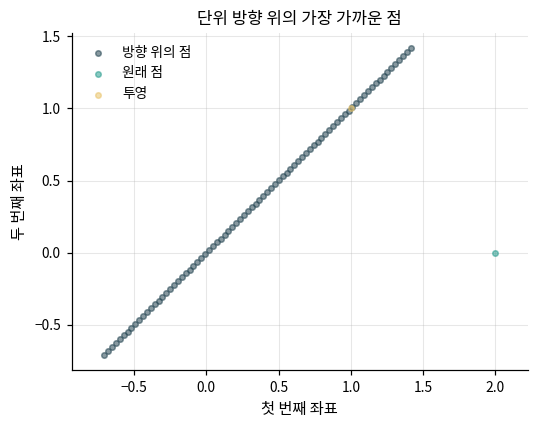

In [4]:
line = np.linspace(-1, 2, 80)[:, None] * q.T
plot_clouds([('단위 방향 위의 가장 가까운 점', {'방향 위의 점': line, '원래 점': x, '투영': x_hat})])

그림의 투영점과 원래 점을 잇는 선분은 방향에 수직입니다. 차원을 줄이면 이 수직 성분이 복원 오차로 남습니다.

### 일반적인 열들의 조합: 최소제곱

열들이 단위·직교 방향일 때는 내적만으로 좌표를 얻었습니다. 일반적인 행렬 $A\in\mathbb R^{N\times k}$의 열을 섞어 $y\in\mathbb R^{N\times1}$를 맞추면
$\min_w\tfrac12\|Aw-y\|^2$의 기울기는 $A^T(Aw-y)$입니다.
열들이 선형 독립이면 $A^TAw=A^Ty$를 풀어 계수를 얻습니다. `solve(M, b)`는 $Mw=b$의 해를 계산합니다.
`lstsq`는 최소제곱을 직접 푸는 분해 기반 함수입니다. 두 계산을 작은 예제로 대조합니다.

In [5]:
def normal_equation(A, y):
    return np.linalg.solve(A.T @ A, A.T @ y)

In [6]:
A = np.column_stack([np.ones(4), np.array([-1., 0., 1., 2.])])
y = np.array([[0.], [1.], [1.], [3.]])
w = normal_equation(A, y)
w_reference = np.linalg.lstsq(A, y, rcond=None)[0]
np.testing.assert_allclose(w, w_reference)
np.testing.assert_allclose(A.T @ (A @ w - y), 0, atol=1e-14)
print('최소제곱 계수:', w.ravel())

최소제곱 계수: [0.8 0.9]


## 2. 분산을 행렬로 모으기

학습 관측 $N$개를 같은 확률 $1/N$로 고르는 경험 분포를 생각합니다.
$\mu_j=\tfrac1N\sum_nX_{nj}$이고, 공분산의 $(i,j)$ 성분은
$C_{ij}=\tfrac1N\sum_n(X_{ni}-\mu_i)(X_{nj}-\mu_j)$입니다.
같이 커지는 두 좌표에는 양의 공분산이 생깁니다. 대각선 $C_{jj}$는 각 좌표의 분산입니다.

배열로는 $C=X_c^TX_c/N$입니다. `Xc.T @ Xc`는 관측 축 $n$을 합합니다.
여기서는 경험 분포와 Gaussian 최대우도에 맞춰 **분모 $N$**을 사용합니다.
모집단 공분산의 불편 추정량을 다룰 때 쓰는 $N-1$ 규약은 같은 합에 $N/(N-1)$을 곱한 값입니다.

모든 $v$에 대해 $v^TCv=\|X_cv\|^2/N\ge0$입니다. 이런 대칭 행렬을 양의 준정부호라고 합니다.

In [7]:
def covariance(X):
    mu = X.mean(axis=0)
    Xc = X - mu
    return mu, Xc.T @ Xc / len(X)


def covariance_loops(X):
    mu = X.mean(axis=0)
    C = np.zeros((X.shape[1], X.shape[1]))
    for n in range(len(X)):
        for i in range(X.shape[1]):
            for j in range(X.shape[1]):
                C[i, j] += (X[n, i] - mu[i]) * (X[n, j] - mu[j]) / len(X)
    return C

In [8]:
small = np.array([[1., 2.], [3., 0.], [5., 4.]])
mu, C = covariance(small)
np.testing.assert_allclose(mu, [3., 2.])
np.testing.assert_allclose(C, [[8/3, 4/3], [4/3, 8/3]])
np.testing.assert_allclose(C, covariance_loops(small))
np.testing.assert_allclose(C, np.cov(small, rowvar=False, ddof=0))
np.testing.assert_allclose(covariance(np.repeat(small, 2, axis=0))[1], C)
print('경험 공분산:\n', C)

경험 공분산:
 [[2.66667 1.33333]
 [1.33333 2.66667]]


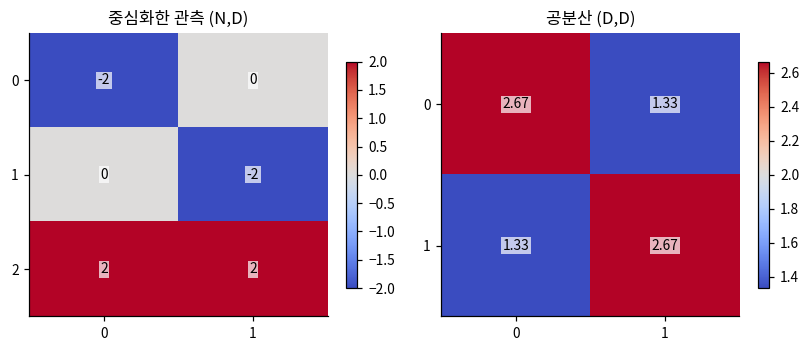

In [9]:
plot_matrices([small - mu, C], ['중심화한 관측 (N,D)', '공분산 (D,D)'])

대각선은 두 좌표의 분산, 대각선 밖은 좌표 사이의 공분산입니다. 관측을 그대로 두 번 모으면 경험 분포가 같으므로 분모 $N$의 공분산도 같습니다.

## 3. 고유벡터와 SVD: 방향을 계산하기

$Cv=\lambda v$이면 $v$는 변환 $C$를 거친 뒤에도 같은 직선에 놓이는 **고유벡터**, $\lambda$는 그 방향의 배율인 **고유값**입니다.
단위 $v$에서는 $\lambda=v^TCv$가 투영 좌표의 분산입니다.
`np.linalg.eigh(C)`는 대칭 행렬의 고유값과 서로 직교하는 단위 고유벡터를 반환합니다. 고유값은 오름차순입니다.

관측 행렬 자체의 **특이값 분해(SVD)** 는 $X_c=U\operatorname{diag}(s)V^T$입니다.
`full_matrices=False`를 사용하면 $r=\min(N,D)$에 대해 $U:(N,r)$, $s:(r,)$, $V^T:(r,D)$입니다. 특이값 $s$는 내림차순입니다.
`U * s`는 $U$의 각 열에 해당 특이값을 곱합니다.

$X_c^TX_c/N=V\operatorname{diag}(s^2/N)V^T$이므로 오른쪽 특이벡터가 공분산의 방향입니다.
분해 계산은 `numpy.linalg`를 사용하고, 반환값의 정의·shape·재구성·학습 목적의 연결을 직접 검산합니다.

In [10]:
rng = np.random.default_rng(110)
angle = 0.65
rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
X_train = rng.normal(size=(240, 2)) * np.array([2.2, 0.35]) @ rotation.T + np.array([2., -1.])
X_valid = rng.normal(size=(160, 2)) * np.array([2.2, 0.35]) @ rotation.T + np.array([2., -1.])
mean_train, C_train = covariance(X_train)
Xc = X_train - mean_train
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
eigenvalues, eigenvectors = np.linalg.eigh(C_train)
np.testing.assert_allclose((U * s) @ Vt, Xc, atol=1e-13)
np.testing.assert_allclose(Vt @ Vt.T, np.eye(2), atol=1e-13)
np.testing.assert_allclose(s**2 / len(X_train), eigenvalues[::-1])
np.testing.assert_allclose(C_train @ Vt.T, Vt.T * (s**2 / len(X_train)), atol=1e-13)
print('특이값:', s, '분산:', s**2 / len(X_train))

특이값: [34.19616  5.7151 ] 분산: [4.87241 0.13609]


고유벡터 $v$와 $-v$는 같은 방향의 직선을 나타냅니다. 중복 고유값이 있으면 그 부분공간 안에서 기저가 회전할 수도 있습니다.
따라서 검산에는 좌표의 부호보다 $QQ^T$와 복원 결과를 사용합니다.

**rank(계수)** 는 선형 독립인 방향의 수입니다. 중심화하면 관측들의 합이 0이므로 rank는 최대 $\min(N-1,D)$입니다.
아래의 rank-1 행렬은 두 열이 같은 정보이며, 두 번째 특이값이 수치적으로 0에 가깝습니다.
작은 특이값을 나누는 연산은 오차를 크게 만들 수 있습니다. `lstsq`의 `rcond`는 해 계산에 사용할 특이값의 상대 기준을 정합니다.

In [11]:
rank_one = np.array([[-2., -4.], [0., 0.], [2., 4.]])
rank_s = np.linalg.svd(rank_one, compute_uv=False)
tolerance = max(rank_one.shape) * np.finfo(float).eps * rank_s[0]
assert np.count_nonzero(rank_s > tolerance) == 1
print('rank-1 특이값:', rank_s, '판정 기준:', tolerance)

rank-1 특이값: [6.32456 0.     ] 판정 기준: 4.213000162292041e-15


## 4. PCA의 목적: 복원 오차가 작은 부분공간

$Q^TQ=I_k$라는 조건에서 $\|X_c-X_cQQ^T\|_F^2/N$을 줄입니다.
$\|M\|_F^2=\sum_{ij}M_{ij}^2$는 행렬 전체 성분의 제곱합입니다.
직교하는 투영과 잔차의 제곱 길이는 더해지므로

$$\frac{\|X_c-X_cQQ^T\|_F^2}{N}
=\frac{\|X_c\|_F^2}{N}-\frac{\|X_cQ\|_F^2}{N}.$$

왼쪽을 줄이는 것은 남기는 분산을 키우는 것과 같습니다. 공분산의 고유기저에서 방향별 분산은 $\lambda_j$이므로 큰 $k$개를 선택합니다.
이 계산이 **PCA(주성분 분석)** 입니다. 남긴 분산의 비율은 $\sum_{j\le k}\lambda_j/\sum_j\lambda_j$, 남은 오차는 $\sum_{j>k}\lambda_j$입니다.
여기서 오차는 **관측별 제곱 거리의 평균**이며, 전체 원소 MSE는 이 값을 $D$로 나눕니다.

In [12]:
def pca_fit(X, k):
    if not 1 <= k <= min(X.shape):
        raise ValueError('k는 1부터 min(N,D)까지의 정수로 지정합니다.')
    mu = X.mean(axis=0)
    _, singular_values, Vt = np.linalg.svd(X - mu, full_matrices=False)
    Q = Vt[:k].T
    return mu, Q


def pca_transform_and_reconstruct(X, mu, Q):
    Z, centered_reconstruction = project(X - mu, Q)
    return Z, centered_reconstruction + mu

In [13]:
mu_pca, Q_pca = pca_fit(X_train, k=1)
Z_train, reconstructed_train = pca_transform_and_reconstruct(X_train, mu_pca, Q_pca)
Z_valid, reconstructed_valid = pca_transform_and_reconstruct(X_valid, mu_pca, Q_pca)
train_distance = np.mean(np.sum((X_train - reconstructed_train)**2, axis=1))
valid_distance = np.mean(np.sum((X_valid - reconstructed_valid)**2, axis=1))
retained_fraction = s[0]**2 / np.sum(s**2)
np.testing.assert_allclose(train_distance, np.sum(s[1:]**2) / len(X_train), rtol=1e-12)
np.testing.assert_allclose((X_train - reconstructed_train) @ Q_pca, 0, atol=1e-13)
_, fully_reconstructed = pca_transform_and_reconstruct(X_valid, *pca_fit(X_train, k=2))
np.testing.assert_allclose(fully_reconstructed, X_valid, atol=1e-13)
print(f'1차원 압축: 유지 분산 {retained_fraction:.4%}, 학습 거리 오차 {train_distance:.6f}, 검증 거리 오차 {valid_distance:.6f}')

1차원 압축: 유지 분산 97.2828%, 학습 거리 오차 0.136093, 검증 거리 오차 0.125096


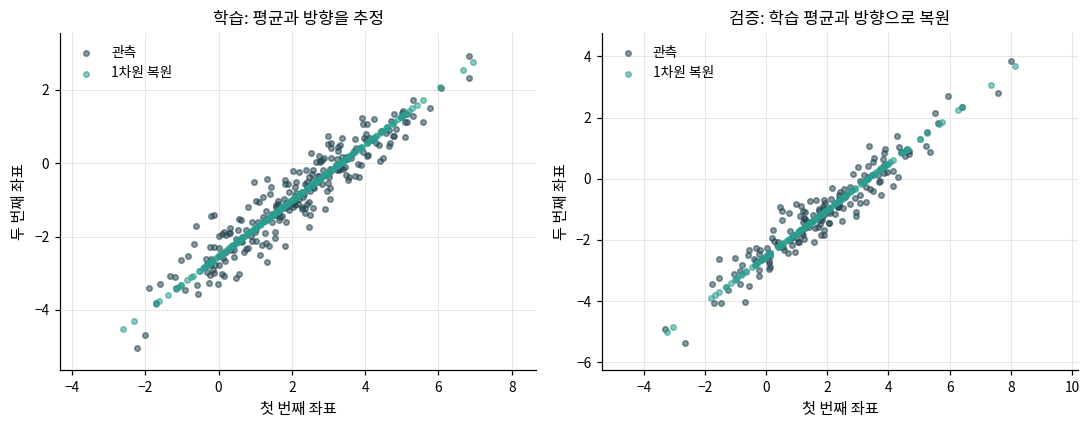

In [14]:
plot_clouds([
    ('학습: 평균과 방향을 추정', {'관측': X_train, '1차원 복원': reconstructed_train}),
    ('검증: 학습 평균과 방향으로 복원', {'관측': X_valid, '1차원 복원': reconstructed_valid}),
])

점들의 긴 방향을 남기고 짧은 방향을 평균으로 복원했습니다. 검증 데이터에도 학습에서 얻은 같은 $\mu,Q$를 사용합니다.
PCA는 학습 데이터의 복원 제곱 오차를 최적화합니다. 이후 분류에 유용한 방향은 라벨과 목적함수까지 고려해 확인합니다.

### 고정된 기저를 통과하는 미분

$Z=X_cQ$ 뒤에서 $G=\partial L/\partial Z$가 왔다면
$dX_c=GQ^T$, $dQ=X_c^TG$입니다. 원소별로 $dZ_{nk}=\sum_d(dX_{nd}Q_{dk}+X_{nd}dQ_{dk})$를 펼치면 두 식을 얻습니다.
이 절은 **이미 정한 $Q$를 사용하는 행렬곱**의 미분을 확인합니다. SVD로 $Q$를 선택하는 과정의 미분은 별도의 문제입니다.

In [15]:
def projection_backward(Xc, Q, G):
    return G @ Q.T, Xc.T @ G

In [16]:
X_check = rng.normal(size=(3, 4))
Q_check = rng.normal(size=(4, 2))
G_check = rng.normal(size=(3, 2))
dX, dQ = projection_backward(X_check, Q_check, G_check)
error_x = rel_error(dX, numerical_gradient(lambda: np.sum((X_check @ Q_check) * G_check), X_check))
error_q = rel_error(dQ, numerical_gradient(lambda: np.sum((X_check @ Q_check) * G_check), Q_check))
assert max(error_x, error_q) < 1e-7
print('행렬곱 backward 상대 오차:', max(error_x, error_q))

행렬곱 backward 상대 오차: 1.3094692194474316e-10


## 5. 단위를 바꾸면 남기는 방향도 바뀝니다

한 열을 10배 하면 그 열의 분산은 100배입니다. PCA가 최적화하는 거리도 바뀝니다.
표준화는 학습 평균을 빼고 학습 표준편차로 나누어, 열마다 분산 1의 좌표계에서 분석하는 선택입니다.
원래 좌표의 거리와 표준화 좌표의 거리는 서로 다른 목적입니다. 어느 목적이 문제에 맞는지 먼저 정합니다.

In [17]:
scale = np.array([1., 10.])
X_scaled = X_train * scale
mu_scaled, Q_scaled = pca_fit(X_scaled, 1)
standard_deviation = X_scaled.std(axis=0)
X_standardized = (X_scaled - mu_scaled) / standard_deviation
mu_standard, Q_standard = pca_fit(X_standardized, 1)
_, scaled_reconstruction = pca_transform_and_reconstruct(X_scaled, mu_scaled, Q_scaled)
_, standardized_reconstruction = pca_transform_and_reconstruct(X_standardized, mu_standard, Q_standard)
back_to_original = (standardized_reconstruction * standard_deviation + mu_scaled) / scale
np.testing.assert_allclose(X_standardized.var(axis=0), 1)
print('원래 열 단위에서 PCA 방향:', Q_pca.ravel())
print('두 번째 열을 10배 한 좌표계의 방향:', Q_scaled.ravel())

원래 열 단위에서 PCA 방향: [-0.79519 -0.60636]
두 번째 열을 10배 한 좌표계의 방향: [-0.12097 -0.99266]


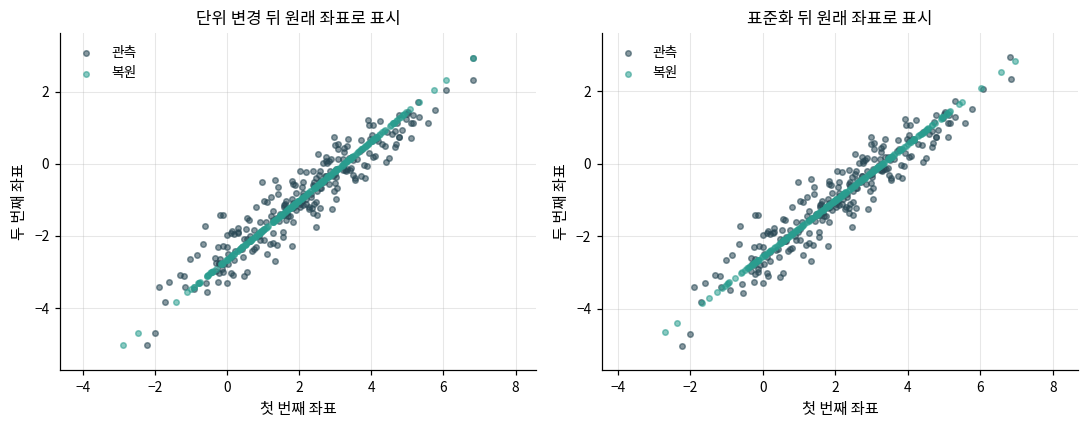

In [18]:
plot_clouds([
    ('단위 변경 뒤 원래 좌표로 표시', {'관측': X_train, '복원': scaled_reconstruction / scale}),
    ('표준화 뒤 원래 좌표로 표시', {'관측': X_train, '복원': back_to_original}),
])

## 6. 직접 바꾸기: 3차원에서 두 방향 남기기

새 셀에 `my_pca_fit(X, k)`를 작성해 `(mu, Q)`를 반환해 보세요. 공분산의 `eigh`를 쓰면 SVD와 다른 경로로 구현할 수 있습니다.
`eigh`의 고유값 순서와 $Q$의 열 방향을 먼저 적습니다. 아래 검사기는 실제로 전달한 함수로 압축·복원합니다.
검사 이후에는 학습 3차원 점을 만들고 $k=1,2,3$의 검증 복원 오차를 비교해 보세요.

In [19]:
def check_pca_fit(candidate):
    local_rng = np.random.default_rng(117)
    for N, D, k in [(7, 3, 1), (9, 4, 2), (6, 3, 3)]:
        X = local_rng.normal(size=(N, D)) * np.arange(1, D + 1) + np.arange(D) * 4
        mu, Q = candidate(X.copy(), k)
        assert np.shape(mu) == (D,) and np.shape(Q) == (D, k)
        np.testing.assert_allclose(mu, X.mean(axis=0), atol=1e-12)
        np.testing.assert_allclose(Q.T @ Q, np.eye(k), atol=1e-10)
        _, V = np.linalg.eigh(covariance(X)[1])
        reference_Q = V[:, -k:]
        np.testing.assert_allclose(Q @ Q.T, reference_Q @ reference_Q.T, atol=1e-9)
        _, reconstructed = pca_transform_and_reconstruct(X, mu, Q)
        reference_loss = np.sum(np.linalg.eigvalsh(covariance(X)[1])[:D-k])
        np.testing.assert_allclose(np.mean(np.sum((X - reconstructed)**2, axis=1)), reference_loss, atol=1e-10)
    return '통과: 평균·직교성·선택 부분공간·실제 복원'

In [20]:
print(check_pca_fit(pca_fit))
X3_train = rng.normal(size=(100, 3)) @ np.array([[2., 1., 0.], [0., .5, .3], [.1, 0., .1]]) + [1., 3., -2.]
X3_valid = rng.normal(size=(60, 3)) @ np.array([[2., 1., 0.], [0., .5, .3], [.1, 0., .1]]) + [1., 3., -2.]
rank_errors = []
for k in [1, 2, 3]:
    _, reconstructed = pca_transform_and_reconstruct(X3_valid, *pca_fit(X3_train, k))
    rank_errors.append(np.mean(np.sum((X3_valid - reconstructed)**2, axis=1)))
assert np.all(np.diff(rank_errors) <= 1e-12)
print('3차원 검증 거리 오차 k=1,2,3:', rank_errors)

통과: 평균·직교성·선택 부분공간·실제 복원
3차원 검증 거리 오차 k=1,2,3: [np.float64(0.24538287804575815), np.float64(0.010660790846797765), np.float64(1.2443048184697054e-30)]


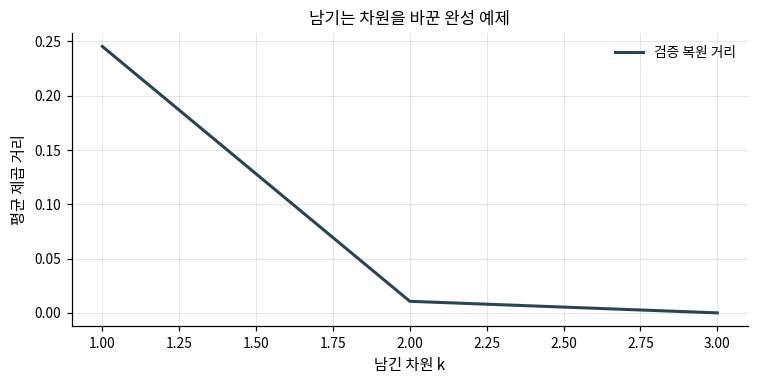

In [21]:
plot_curves([1, 2, 3], {'검증 복원 거리': rank_errors}, title='남기는 차원을 바꾼 완성 예제', xlabel='남긴 차원 k', ylabel='평균 제곱 거리')

**준비도 확인**

- $Q$의 열이 직교하는 단위 벡터일 때 투영 좌표가 내적이 되는 이유를 미분으로 설명할 수 있나요?
- $X_c^TX_c$에서 합하는 축과 $N$으로 나누는 이유를 설명할 수 있나요?
- SVD의 $s^2/N$이 공분산의 고유값이 되는 식을 전개할 수 있나요?
- $Q$의 부호가 바뀌어도 같은 복원이 나오는 것을 코드로 확인할 수 있나요?
- 유지 분산·복원 거리·원소 MSE의 차이를 숫자로 확인할 수 있나요?

다음 [12 다변량 Gaussian·정보이론](12_gaussian_information.ipynb)에서는 공분산을 샘플 생성과 로그 밀도 계산에 사용합니다.
이후 Autoencoder에서는 $Z=X_cQ$를 학습 가능한 비선형 encoder로 확장합니다.

수학 참고: [Boyd·Vandenberghe, Introduction to Applied Linear Algebra](https://web.stanford.edu/~boyd/vmls/)의 직교성·최소제곱, [Stanford CS229의 다변량 Gaussian 노트](https://cs229.stanford.edu/section/gaussians.pdf)의 공분산 정의.